# 12. Live Tutorial 2: ANOVA & Regression — One Process Study, Start to Finish

This session follows a single materials-engineering investigation —
**friction-stir welding of Al 6061-T6 panels** — through every technique
in this notebook's title. That is deliberate: ANOVA and regression are not
two unrelated tools that happen to share a chapter. They are the **same
underlying model** (the *general linear model*), and Section 12.4 proves it
directly. Seeing both applied to one coherent process study, rather than
four disconnected toy datasets, is the point of this "live tutorial"
format.

Sections 12.1–12.6 are core material; 12.7 is a short "going further"
bonus; the exercise list is substantial self-study material.

**Investigation log**
1. Recap: why not just run six pairwise *t*-tests? (multiple comparisons)
2. Which tool pin design gives the strongest joint? (one-way ANOVA)
3. Controlling for coil-to-coil variation (randomized block design)
4. The bridge: ANOVA *is* regression
5. Building a predictive model from process parameters (multiple regression
   + variable selection)
6. Does tool design still matter once rotation speed is accounted for?
   (ANCOVA)
7. *Going further*: three factors at once (three-way ANOVA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(11)

## 12.1 Recap: Why Not Just Run Six *t*-Tests?

The welding team wants to compare four pin-tool designs. Comparing all
pairs would mean $\binom{4}{2}=6$ separate *t*-tests. Notebook 11, Exercise 6
already showed the problem numerically: with six independent tests at
$\alpha=0.05$ each, the chance of *at least one* false positive is
$1-(1-0.05)^6\approx 26\%$ — a coin flip's worth of "significant" results
that are actually noise. **ANOVA** solves this with a single **omnibus
test**: one F-statistic asking "is there evidence *any* group differs?" at
a controlled, single $\alpha$ — and only if that test is significant do you
proceed to pairwise comparisons, using a correction (Tukey's HSD, Section
12.2) that accounts for having looked at all six pairs.

## 12.2 Which Pin Design Gives the Strongest Joint? One-Way ANOVA

Four tool pin geometries — **Cylindrical, Threaded, Triflute, Flared** —
are each used to weld 10 panel pairs (process parameters held fixed).
Response: joint ultimate tensile strength as a **percentage of the parent
metal's strength** (a standard way welding strength is reported, since it
normalises out base-material variation).

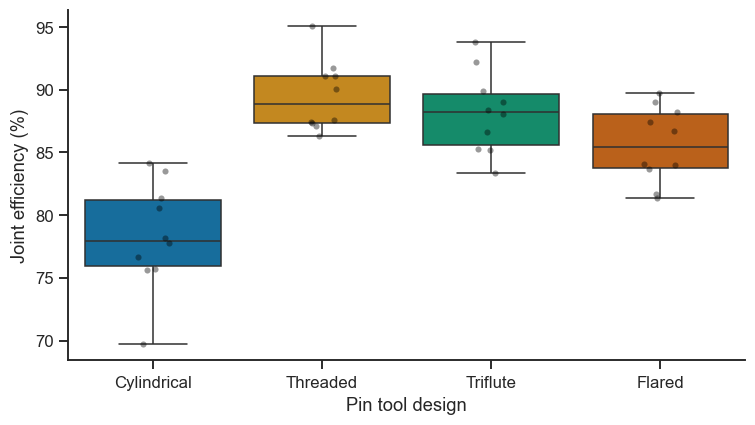

                  mean       std  count
tool_design                            
Cylindrical  78.313301  4.302429     10
Threaded     89.463776  2.789919     10
Triflute     88.169902  3.228943     10
Flared       85.580415  3.032644     10


In [2]:
tool_designs = ['Cylindrical', 'Threaded', 'Triflute', 'Flared']
true_means   = [78, 88, 92, 85]     # % of parent-metal strength
n_per_group  = 10
sigma        = 4.5

rows = []
for design, mu in zip(tool_designs, true_means):
    strengths = rng.normal(mu, sigma, n_per_group)
    rows.extend({'tool_design': design, 'joint_efficiency_pct': s} for s in strengths)
df_tools = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_tools, x='tool_design', y='joint_efficiency_pct',
            order=tool_designs, hue='tool_design', palette='colorblind',
            legend=False, ax=ax)
sns.stripplot(data=df_tools, x='tool_design', y='joint_efficiency_pct',
              order=tool_designs, color='black', alpha=0.4, size=4, ax=ax)
ax.set_xlabel('Pin tool design'); ax.set_ylabel('Joint efficiency (%)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(df_tools.groupby('tool_design')['joint_efficiency_pct'].agg(['mean', 'std', 'count']).loc[tool_designs])

In [3]:
# ── Assumption checks before trusting the F-test ──────────────────────────────
groups = [df_tools.loc[df_tools.tool_design == d, 'joint_efficiency_pct'] for d in tool_designs]
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's test (equal variance across groups): p={levene_p:.3f}")

model = smf.ols('joint_efficiency_pct ~ C(tool_design)', data=df_tools).fit()
shapiro_stat, shapiro_p = stats.shapiro(model.resid)
print(f'Shapiro-Wilk on residuals (normality): p={shapiro_p:.3f}')
print('Both checks pass -> a standard one-way ANOVA is appropriate here.')

Levene's test (equal variance across groups): p=0.730
Shapiro-Wilk on residuals (normality): p=0.392
Both checks pass -> a standard one-way ANOVA is appropriate here.


In [4]:
# ── One-way ANOVA ──────────────────────────────────────────────────────────────
f_stat, p_value = stats.f_oneway(*groups)
print(f'F-statistic: {f_stat:.2f}')
print(f'p-value:     {p_value:.6f}')

# Effect size: eta-squared = SS_between / SS_total
anova_table = sm.stats.anova_lm(model, typ=2)
eta_sq = anova_table.loc['C(tool_design)', 'sum_sq'] / anova_table['sum_sq'].sum()
print(f'\neta-squared (variance explained by tool design): {eta_sq:.2f}')
print(anova_table)

F-statistic: 21.62
p-value:     0.000000

eta-squared (variance explained by tool design): 0.64
                    sum_sq    df         F        PR(>F)
C(tool_design)  744.391782   3.0  21.61532  3.522853e-08
Residual        413.257889  36.0       NaN           NaN


In [5]:
# ── Which pairs actually differ? Tukey HSD (controls the family-wise error) ───
tukey = pairwise_tukeyhsd(df_tools['joint_efficiency_pct'], df_tools['tool_design'], alpha=0.05)
print(tukey)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1    group2  meandiff p-adj   lower   upper  reject
-----------------------------------------------------------
Cylindrical   Flared   7.2671 0.0002  3.1863 11.3479   True
Cylindrical Threaded  11.1505    0.0  7.0697 15.2313   True
Cylindrical Triflute   9.8566    0.0  5.7758 13.9374   True
     Flared Threaded   3.8834  0.067 -0.1975  7.9642  False
     Flared Triflute   2.5895  0.334 -1.4913  6.6703  False
   Threaded Triflute  -1.2939 0.8282 -5.3747  2.7869  False
-----------------------------------------------------------


**Checkpoint**: the omnibus F-test says the four designs are not all
equal ($p\ll0.05$), and $\eta^2$ says tool design explains a large share
of the variance in joint efficiency. Tukey's table then tells you *which*
pairs are distinguishable — read off which comparisons have
`reject=True`. Note this is exactly the workflow the multiple-comparisons
problem in Section 12.1 warned you not to skip: omnibus test **first**,
corrected pairwise comparisons **second**, never six raw *t*-tests.

## 12.3 Controlling for Coil-to-Coil Variation: Randomized Block Design

Next question: does **rotation speed** (900 / 1200 / 1500 rpm) affect
strength? The catch: aluminium coil stock varies batch-to-batch (thickness,
temper, trace composition), and the welding team only has four coils
available, each large enough for one weld at *each* of the three speeds.
Coil is a real source of variation you are not interested in but cannot
avoid — a **nuisance variable**. Ignoring it (treating this as an ordinary
one-way ANOVA over 12 independent welds) would let coil-to-coil variation
inflate the error term and potentially hide a genuine rotation-speed
effect — exactly the same problem Notebook 11 §11.5 solved with *pairing*,
generalised to more than two groups. The fix is a **randomized complete
block design (RCBD)**: treat coil as a **block**, weld every speed on
every coil, and remove block-to-block variation from the error term
explicitly.

In [6]:
speeds = [900, 1200, 1500]        # rpm -- the factor of interest
coils  = ['Coil-1', 'Coil-2', 'Coil-3', 'Coil-4']   # the blocking factor
coil_effect = dict(zip(coils, [-3, 5, 8, -2]))       # each coil's own baseline offset
speed_effect = dict(zip(speeds, [80, 86, 90]))        # true effect of speed

rows = []
for coil in coils:
    for speed in speeds:
        strength = speed_effect[speed] + coil_effect[coil] + rng.normal(0, 2.5)
        rows.append({'coil': coil, 'rotation_speed': speed, 'strength_MPa': strength})
df_block = pd.DataFrame(rows)
print(df_block.pivot(index='coil', columns='rotation_speed', values='strength_MPa').round(1))

rotation_speed  900   1200  1500
coil                            
Coil-1          77.9  83.6  89.7
Coil-2          81.8  89.3  92.9
Coil-3          83.7  94.3  99.3
Coil-4          76.2  87.5  90.1


In [7]:
# ── RCBD: rotation speed (factor) + coil (block), no interaction term ─────────
# 'rotation_speed' is coded as a category here -- we care about 3 discrete
# settings, not (yet) a continuous trend; Section 12.5 revisits speed as
# a continuous regression predictor.
model_block = smf.ols('strength_MPa ~ C(rotation_speed) + C(coil)', data=df_block).fit()
anova_block = sm.stats.anova_lm(model_block, typ=2)
print(anova_block)

# Compare to (incorrectly) ignoring the block entirely
model_noblock = smf.ols('strength_MPa ~ C(rotation_speed)', data=df_block).fit()
anova_noblock = sm.stats.anova_lm(model_noblock, typ=2)
print('\nSame data, ignoring the coil block:')
print(anova_noblock)

                       sum_sq   df          F    PR(>F)
C(rotation_speed)  358.674123  2.0  79.747779  0.000048
C(coil)            140.912525  3.0  20.887040  0.001411
Residual            13.492819  6.0        NaN       NaN

Same data, ignoring the coil block:
                       sum_sq   df          F    PR(>F)
C(rotation_speed)  358.674123  2.0  10.453223  0.004499
Residual           154.405344  9.0        NaN       NaN


In [8]:
print(f"Residual mean square WITH block:    {anova_block.loc['Residual','sum_sq'] / anova_block.loc['Residual','df']:.2f}")
print(f"Residual mean square WITHOUT block: {anova_noblock.loc['Residual','sum_sq'] / anova_noblock.loc['Residual','df']:.2f}")
print(f"\nRotation speed p-value WITH block:    {anova_block.loc['C(rotation_speed)','PR(>F)']:.5f}")
print(f"Rotation speed p-value WITHOUT block: {anova_noblock.loc['C(rotation_speed)','PR(>F)']:.5f}")
print('\nBlocking removed coil-to-coil variation from the error term, shrinking the')
print('residual mean square and making the same rotation-speed effect easier to detect --')
print('the ANOVA generalisation of the paired-vs-unpaired comparison from Notebook 11.')

Residual mean square WITH block:    2.25
Residual mean square WITHOUT block: 17.16

Rotation speed p-value WITH block:    0.00005
Rotation speed p-value WITHOUT block: 0.00450

Blocking removed coil-to-coil variation from the error term, shrinking the
residual mean square and making the same rotation-speed effect easier to detect --
the ANOVA generalisation of the paired-vs-unpaired comparison from Notebook 11.


**Checkpoint / Exercise A**: Increase the spread of `coil_effect` in
Section 12.3 (e.g. `[-15, 20, 25, -10]`) and re-run. What happens to the gap
between the "with block" and "without block" p-values as coil-to-coil
variation grows? Compare your answer to Notebook 11, Exercise B, which asked
the identical question about paired vs. unpaired *t*-tests.

## 12.4 The Bridge: ANOVA *Is* Regression

Here is the idea this whole notebook has been building toward. `smf.ols`
has been used for *every* ANOVA so far — because underneath, `C(tool_design)`
means "create dummy (0/1) variables for the categories and fit an ordinary
regression on them." Let's see it explicitly for the one-way tool-design
data from Section 12.2.

In [9]:
# Look at the actual design matrix statsmodels builds behind C(tool_design)
design_matrix = smf.ols('joint_efficiency_pct ~ C(tool_design)', data=df_tools).exog
design_df = pd.DataFrame(design_matrix[:5],
                          columns=smf.ols('joint_efficiency_pct ~ C(tool_design)', data=df_tools).exog_names)
print('First 5 rows of the regression design matrix:')
print(design_df)
print('\ncorresponding tool_design values:', df_tools['tool_design'].iloc[:5].tolist())

First 5 rows of the regression design matrix:
   Intercept  C(tool_design)[T.Flared]  C(tool_design)[T.Threaded]  \
0        1.0                       0.0                         0.0   
1        1.0                       0.0                         0.0   
2        1.0                       0.0                         0.0   
3        1.0                       0.0                         0.0   
4        1.0                       0.0                         0.0   

   C(tool_design)[T.Triflute]  
0                         0.0  
1                         0.0  
2                         0.0  
3                         0.0  
4                         0.0  

corresponding tool_design values: ['Cylindrical', 'Cylindrical', 'Cylindrical', 'Cylindrical', 'Cylindrical']


In [10]:
# The F-test from `stats.f_oneway` and the F-test from an OLS regression on
# these dummy variables are numerically identical.
f_anova, p_anova = stats.f_oneway(*groups)
f_regression = model.fvalue     # `model` is the same OLS fit from Section 12.2
p_regression = model.f_pvalue

print(f'f_oneway:        F={f_anova:.4f}, p={p_anova:.6f}')
print(f'OLS regression:  F={f_regression:.4f}, p={p_regression:.6f}')
print(f'\nIdentical (to floating-point precision): {np.isclose(f_anova, f_regression)}')
print('\nThis is why statsmodels can run every ANOVA in this notebook through the')
print('exact same `ols()` + `anova_lm()` pair you would use for a regression --')
print('there is only one underlying model.')

f_oneway:        F=21.6153, p=0.000000
OLS regression:  F=21.6153, p=0.000000

Identical (to floating-point precision): True

This is why statsmodels can run every ANOVA in this notebook through the
exact same `ols()` + `anova_lm()` pair you would use for a regression --
there is only one underlying model.


## 12.5 Building a Predictive Model: Multiple Regression + Variable Selection

Now treat the process parameters as **continuous** and build a model that
*predicts* joint strength anywhere in the operating window, not just at
the specific settings tested. Start from a **saturated model** with every
candidate term the welding engineers can think of — including two that
turn out to be red herrings, deliberately, to demonstrate what variable
selection is supposed to catch.

In [11]:
n = 60
rotation_rpm  = rng.uniform(800, 1600, n)
traverse_mm_min = rng.uniform(50, 300, n)
axial_force_kN  = rng.uniform(4, 12, n)
plate_thickness_mm = rng.uniform(3, 8, n)      # a genuine predictor
ambient_humidity_pct = rng.uniform(30, 70, n)  # a red herring -- no real effect

rotation_c = (rotation_rpm - rotation_rpm.mean()) / rotation_rpm.std()
traverse_c = (traverse_mm_min - traverse_mm_min.mean()) / traverse_mm_min.std()

# True model: rotation, traverse, force, thickness matter; humidity does NOT.
# A mild rotation x traverse interaction is baked in (heat input depends on both).
strength_true = (86
                  + 5.0 * rotation_c
                  - 3.0 * traverse_c
                  + 2.5 * rotation_c * traverse_c
                  + 1.2 * (axial_force_kN - axial_force_kN.mean())
                  - 1.8 * (plate_thickness_mm - plate_thickness_mm.mean()))
strength_MPa = strength_true + rng.normal(0, 2.0, n)

df_reg = pd.DataFrame({
    'strength_MPa': strength_MPa,
    'rotation_rpm': rotation_rpm,
    'traverse_mm_min': traverse_mm_min,
    'axial_force_kN': axial_force_kN,
    'plate_thickness_mm': plate_thickness_mm,
    'ambient_humidity_pct': ambient_humidity_pct,
})
print(df_reg.describe().round(2))

       strength_MPa  rotation_rpm  traverse_mm_min  axial_force_kN  \
count         60.00         60.00            60.00           60.00   
mean          86.06       1152.83           164.45            8.13   
std            7.51        250.43            69.55            2.22   
min           68.96        814.37            57.18            4.09   
25%           80.32        927.78           109.44            6.37   
50%           87.90       1086.65           170.35            8.26   
75%           91.64       1394.39           218.96           10.07   
max           96.34       1599.04           294.85           11.93   

       plate_thickness_mm  ambient_humidity_pct  
count               60.00                 60.00  
mean                 5.42                 48.85  
std                  1.46                 11.83  
min                  3.15                 30.09  
25%                  4.05                 38.94  
50%                  5.25                 47.56  
75%                

In [12]:
# ── Saturated model: every candidate main effect + the rotation:traverse interaction ─
full_formula = ('strength_MPa ~ rotation_rpm + traverse_mm_min + axial_force_kN + '
                 'plate_thickness_mm + ambient_humidity_pct + rotation_rpm:traverse_mm_min')
model_full = smf.ols(full_formula, data=df_reg).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:           strength_MPa   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     131.4
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           5.28e-30
Time:                        11:36:22   Log-Likelihood:                -122.68
No. Observations:                  60   AIC:                             259.4
Df Residuals:                      53   BIC:                             274.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

:::{admonition} Take-home message
:class: tip

- R²=0.937 (adjusted 0.930) says the five process parameters plus their interaction explain 93.7% of the variation in joint strength — a strong predictive model even before any variable selection has been applied.
- Notice the "Cond. No. is large, 2.85e+06" warning at the bottom — not a bug, but `rotation_rpm` and `traverse_mm_min` being highly correlated with their own interaction term because neither was centred before multiplying (unlike the centred `rotation_c`/`traverse_c` used only to *generate* the synthetic data in Section 12.5 above). The coefficients and p-values are still valid, but their standard errors are somewhat inflated by this — centring continuous predictors before forming interaction terms is standard practice specifically to avoid this warning.
- `ambient_humidity_pct` has p=0.174, clearly the weakest term in the table — exactly the "red herring" flagged in Section 12.5's introduction, and the first term backward elimination removes below.
:::

### Backward Elimination

`ambient_humidity_pct` almost certainly has the least significant
coefficient above (check its p-value) — exactly as designed, since it has
no real effect on strength. **Backward elimination** is the simplest
variable-selection algorithm: fit the full model, drop the single least
significant term, refit, and repeat until every remaining term is
significant (or a fixed number of terms remain). It is crude compared to
modern penalised methods (LASSO/ridge — beyond this course, but worth
knowing by name), but it is transparent, and transparency matters when you
have to explain a model to a process engineer.

In [13]:
def backward_elimination(data, response, candidate_terms, alpha=0.05, verbose=True):
    """Iteratively drop the least-significant term until all p < alpha."""
    terms = list(candidate_terms)
    while True:
        formula = f'{response} ~ ' + ' + '.join(terms)
        fit = smf.ols(formula, data=data).fit()
        pvalues = fit.pvalues.drop('Intercept')
        worst_term, worst_p = pvalues.idxmax(), pvalues.max()
        if worst_p <= alpha or len(terms) == 1:
            return fit, terms
        if verbose:
            print(f'Dropping {worst_term!r} (p={worst_p:.3f})')
        # statsmodels names interaction terms like 'rotation_rpm:traverse_mm_min' --
        # matches a candidate term string directly, so this simple removal works
        terms.remove(worst_term)


candidates = ['rotation_rpm', 'traverse_mm_min', 'axial_force_kN',
              'plate_thickness_mm', 'ambient_humidity_pct',
              'rotation_rpm:traverse_mm_min']
model_reduced, kept_terms = backward_elimination(df_reg, 'strength_MPa', candidates)
print('\nFinal terms kept:', kept_terms)
print(f'\nFull model:    R2_adj={model_full.rsquared_adj:.3f}, AIC={model_full.aic:.1f}')
print(f'Reduced model: R2_adj={model_reduced.rsquared_adj:.3f}, AIC={model_reduced.aic:.1f}')

Dropping 'ambient_humidity_pct' (p=0.174)

Final terms kept: ['rotation_rpm', 'traverse_mm_min', 'axial_force_kN', 'plate_thickness_mm', 'rotation_rpm:traverse_mm_min']

Full model:    R2_adj=0.930, AIC=259.4
Reduced model: R2_adj=0.929, AIC=259.5


**Checkpoint**: the reduced model should have dropped
`ambient_humidity_pct` (and possibly the interaction, if it wasn't strong
enough to survive) while its adjusted R² and AIC stayed essentially
unchanged — a *lower* AIC would mean a clearly better model, but even a
near-identical AIC with one fewer term is still a win: the same predictive
power from a simpler, cheaper-to-measure model (one less process variable
to monitor on the shop floor). This is the quantitative version of Occam's
razor: prefer the simpler model unless the extra complexity earns its
keep.

## 12.6 Does Tool Design Still Matter? ANCOVA

One more question ties Sections 12.2 and 12.5 together: Section 12.2 found
tool design affects strength — but those welds were also run at whatever
rotation speed happened to be used that day. Is the tool-design effect
*real*, or is it secretly just because certain tools happened to be tested
at better rotation speeds? **ANCOVA** (analysis of covariance) answers
this by putting a categorical factor *and* a continuous covariate in the
same model — literally just a regression formula mixing `C(...)` and
plain terms, one more consequence of Section 12.4's bridge.

In [14]:
# Two tool designs, each tested across a range of rotation speeds
n_tool = 24
tool_ancova = rng.choice(['Threaded', 'Triflute'], size=n_tool)
speed_ancova = rng.uniform(900, 1500, n_tool)
speed_c = (speed_ancova - speed_ancova.mean()) / speed_ancova.std()

tool_bonus = np.where(tool_ancova == 'Triflute', 4.0, 0.0)   # true Triflute advantage
strength_ancova = 85 + tool_bonus + 5.0 * speed_c + rng.normal(0, 2.5, n_tool)
df_ancova = pd.DataFrame({'tool_design': tool_ancova, 'rotation_speed': speed_ancova,
                           'strength_MPa': strength_ancova})

# Naive: ignore rotation speed entirely
model_naive = smf.ols('strength_MPa ~ C(tool_design)', data=df_ancova).fit()
# ANCOVA: control for rotation speed, then ask about tool design
model_ancova = smf.ols('strength_MPa ~ C(tool_design) + rotation_speed', data=df_ancova).fit()

print('Naive one-way ANOVA (ignores rotation speed):')
print(f"  Triflute effect p-value: {model_naive.pvalues.get('C(tool_design)[T.Triflute]', float('nan')):.4f}")
print('\nANCOVA (controls for rotation speed):')
print(f"  Triflute effect p-value: {model_ancova.pvalues['C(tool_design)[T.Triflute]']:.4f}")
print(f"  Rotation speed p-value:  {model_ancova.pvalues['rotation_speed']:.4f}")
print(f"\nTriflute advantage, adjusted for speed: {model_ancova.params['C(tool_design)[T.Triflute]']:.2f} MPa")

Naive one-way ANOVA (ignores rotation speed):
  Triflute effect p-value: 0.0074

ANCOVA (controls for rotation speed):
  Triflute effect p-value: 0.0002
  Rotation speed p-value:  0.0000

Triflute advantage, adjusted for speed: 4.55 MPa


:::{admonition} Take-home message
:class: tip

- Ignoring rotation speed, Triflute's advantage already looks significant (p=0.0074); controlling for speed makes it look *more* significant still (p=0.0002) and pins the advantage at a concrete 4.55 MPa — here, adjusting for the covariate sharpened the conclusion rather than explaining it away.
- That is not guaranteed in general: if the two tools had happened to be tested at systematically different rotation speeds, a naive comparison could show an effect that mostly reflects the speed difference, not the tool itself. ANCOVA's job is to tell those two stories apart — here it confirms the tool effect is real independent of speed.
:::

## 12.7 Going Further: Three Factors at Once

Everything above generalises directly to a **three-way ANOVA** — same
`ols` + `C(...)` + `anova_lm` machinery, just more terms in the formula.
This cell is a compact demonstration rather than a full worked example;
treat it as a template for Exercise 7 below.

In [15]:
# Rotation speed x Traverse speed x Tool design, 2x2x2, n=4 replicates/cell
levels = {'rotation': ['Low', 'High'], 'traverse': ['Low', 'High'], 'tool': ['A', 'B']}
rows = []
for rot in levels['rotation']:
    for trav in levels['traverse']:
        for tool in levels['tool']:
            base = 80 + (5 if rot == 'High' else 0) + (3 if trav == 'High' else 0) + (2 if tool == 'B' else 0)
            # a genuine rotation x tool interaction
            base += 4 if (rot == 'High' and tool == 'B') else 0
            for _ in range(4):
                rows.append({'rotation': rot, 'traverse': trav, 'tool': tool,
                             'strength_MPa': base + rng.normal(0, 2.0)})
df_3way = pd.DataFrame(rows)

model_3way = smf.ols('strength_MPa ~ C(rotation)*C(traverse)*C(tool)', data=df_3way).fit()
print(sm.stats.anova_lm(model_3way, typ=2).round(4))

                                   sum_sq    df        F  PR(>F)
C(rotation)                      292.5915   1.0  52.4043  0.0000
C(traverse)                       73.5620   1.0  13.1752  0.0013
C(tool)                          125.0559   1.0  22.3980  0.0001
C(rotation):C(traverse)            0.0677   1.0   0.0121  0.9132
C(rotation):C(tool)               24.8207   1.0   4.4455  0.0456
C(traverse):C(tool)               15.2145   1.0   2.7250  0.1118
C(rotation):C(traverse):C(tool)    0.0678   1.0   0.0121  0.9132
Residual                         134.0004  24.0      NaN     NaN


:::{admonition} Take-home message
:class: tip

- The table recovers exactly the effects built into the synthetic data above: the rotation, traverse, and tool main effects are all significant (p ≤ 0.0013), the rotation×tool interaction is significant (p=0.046, matching the "genuine rotation x tool interaction" added in the generating code), and every other interaction — including the three-way term — is far from significant (p ≥ 0.11), matching that nothing else was built in.
- This "does the table find what I put in" check is a good habit whenever you control the ground truth (synthetic data, a simulation) — it builds trust in a method before applying it to a real dataset where the ground truth is unknown.
:::

---
## Exercises

**Core practice**

1. **A fifth tool design**: Add a fifth pin design to Section 12.2 with
   `true_mean=90` and re-run the full workflow (boxplot → assumption checks
   → ANOVA → eta-squared → Tukey). Does it change which pairwise
   comparisons are significant among the *original* four designs?

2. **Kruskal-Wallis**: Section 12.2's Shapiro-Wilk check passed, but suppose
   it hadn't. Re-run the comparison with `stats.kruskal(*groups)` (the
   non-parametric analogue of one-way ANOVA, in the same family as
   Notebook 11's Mann-Whitney U) and compare the p-value and conclusion.

3. **Verify the RCBD bridge**: Fit
   `smf.ols('strength_MPa ~ rotation_speed + C(coil)', data=df_block)`
   treating `rotation_speed` as *continuous* rather than `C(rotation_speed)`
   (categorical). Compare the ANOVA table to Section 12.3's. Which model
   assumes a straight-line trend across the three speeds, and which does
   not? When would each be the more appropriate choice?

**Deeper practice**

4. **Forward selection**: Write `forward_selection`, the mirror image of
   `backward_elimination` (Section 12.5): start from an empty model, add
   the single most significant candidate term at each step, stop when no
   remaining candidate would be significant if added. Run it on the same
   `candidates` list and compare the final model to backward elimination's
   — variable-selection algorithms do not always converge on the same
   answer, which is itself an important lesson about their limitations.

5. **Interaction plot**: For the three-way data in Section 12.7, produce an
   interaction plot of mean strength vs. `rotation`, with separate lines
   for each `tool` level, faceted by `traverse` (hint:
   `sns.catplot(..., kind='point', col='traverse', hue='tool', x='rotation')`).
   Where in the plot do you visually see the rotation×tool interaction the
   ANOVA table detected?

6. **Full ANCOVA with interaction**: Section 12.6's ANCOVA assumed the
   rotation-speed *slope* is the same for both tool designs (no
   `C(tool_design):rotation_speed` term). Add that interaction term, refit,
   and check whether it's significant. If it were significant, what would
   that mean physically about how the two tools respond to rotation speed?

7. **Design your own three-way study**: Pick three factors from anywhere
   in this course (material, process parameter, testing condition) and
   build a synthetic 2×2×2 (or 2×2×3) dataset with at least one genuine
   two-way interaction and one genuine main effect that has *no*
   interaction with anything. Fit the full three-way ANOVA and confirm the
   table correctly identifies which effects you built in and which you
   didn't.